# Round 012 — T4 Lazy Prices (ความเปลี่ยนแปลงของ 10-K)

ตัวเลขทั้งหมดอ่านจาก `results.csv` ที่ `run.py` ของ round นี้เขียนไว้ · ช่วงตัดสิน ก.ค. 2017 – มิ.ย. 2023 · ⚠️ survivorship: ราคาของหุ้นที่ออกจากตลาดไปแล้วหายบางส่วน → ผลอาจดูดีเกินจริง · held-out (ตั้งแต่ ก.ค. 2023) ไม่ถูกใช้

In [1]:
import sys, pathlib; sys.path.insert(0, str(pathlib.Path.cwd().parent))
import pandas as pd
from IPython.display import Image, Markdown, display
from lib import report
report.banner()
r = pd.read_csv("../rounds/round_012/results.csv")
cols = [c for c in ["trial_id","dec_sharpe","dec_sharpe_ew","dec_sharpe_spy","dec_cagr","dec_cagr_ew","dec_maxdd","dec_maxdd_ew",
        "S1_10","S1_25","S2_share","DSR","S6_avg_n","S6_min_n","info_sharpe","info_sharpe_ew"] if c in r.columns]
pd.set_option("display.width", 250); pd.set_option("display.max_rows", 200)
display(r[cols].round(3))
ok = lambda c: r[c].astype(str).str.lower().eq("true")
print("ผู้เข้ารอบ (S1+S2+S3+S6):", list(r[ok("S1") & ok("S2") & ok("S3") & ok("S6")].trial_id))


> ⚠️ **คำเตือน survivorship bias (แสดงในทุก notebook)**
> รายชื่อสมาชิกมาจาก fja05680/sp500 (point-in-time) แต่ **ราคามาจาก yfinance ซึ่งเก็บเฉพาะหุ้นที่ยังซื้อขายอยู่**
> หุ้นที่ถูกซื้อกิจการ/ล้มละลาย/เปลี่ยนชื่อจำนวนหนึ่งจึงไม่มีราคา และหลุดออกจาก backtest
> ผลตอบแทนที่คำนวณได้จึงมีแนวโน้ม **สูงกว่าความจริง** (หุ้นที่ "ตาย" ไปมักเป็นหุ้นที่ผลตอบแทนแย่)
> สัดส่วนที่ขาดหายวัดไว้ใน `v0_data_audit.ipynb`

> ⚠️ **ข้อจำกัดของ held-out**: held-out = rebalance มิ.ย. 2023, 2024, 2025 (3 รอบเต็ม) + มิ.ย. 2026 ที่ถือได้แค่ ~3 เดือน
> (รอบ 2026 เป็นข้อมูลประกอบ ไม่นับตัดสิน) — มีแค่ 2–3 รอบ rebalance ที่ใช้ตัดสิน ผลช่วงนี้จึงมีความไม่แน่นอนสูงมาก
> ใช้เป็นการตรวจทิศทางเท่านั้น ไม่ใช่หลักฐานทางสถิติ


,trial_id,dec_sharpe,dec_sharpe_ew,dec_sharpe_spy,dec_cagr,dec_cagr_ew,dec_maxdd,dec_maxdd_ew,S1_10,S1_25,S2_share,DSR,S6_avg_n,S6_min_n,info_sharpe,info_sharpe_ew
0,r012_LAZY_COS_FULL,0.637,0.614,0.681,0.122,0.122,-0.381,-0.384,False,False,0.216,0.002,63.986,50,1.007,1.093
1,r012_LAZY_COS_1A,0.688,0.614,0.681,0.137,0.122,-0.364,-0.384,False,False,0.946,0.039,60.028,50,0.854,1.093


ผู้เข้ารอบ (S1+S2+S3+S6): []


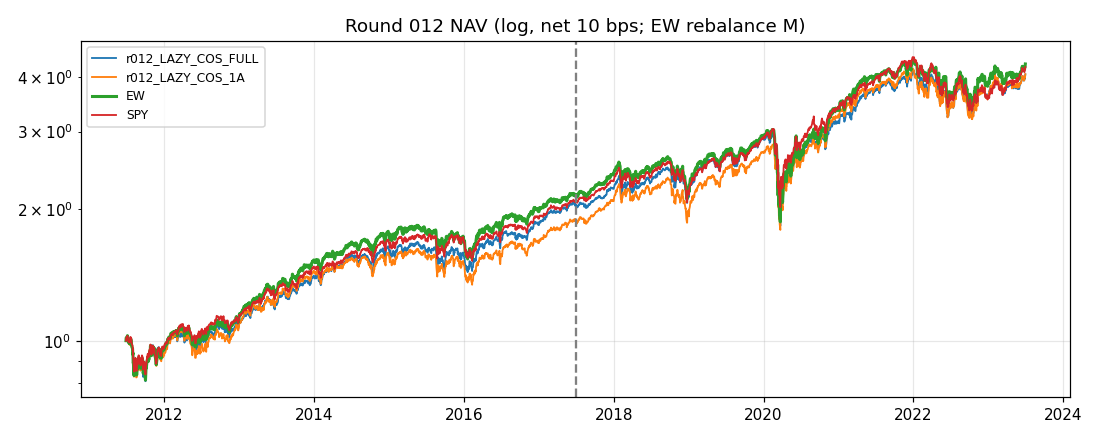

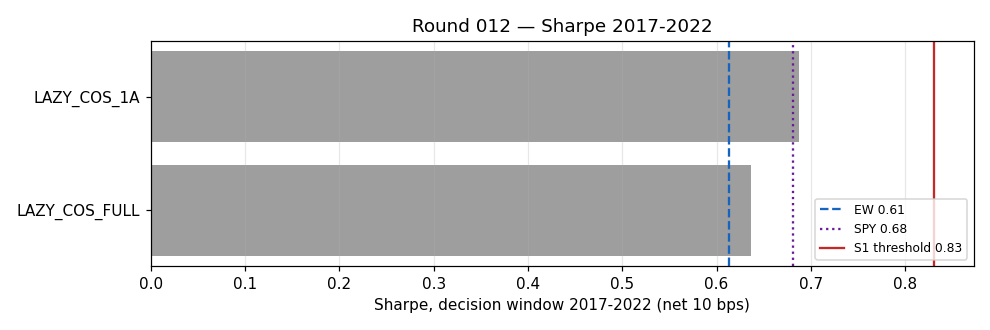

In [2]:
for f in sorted(pathlib.Path("../figures").glob("round_012_*.png")): display(Image(filename=str(f)))

In [3]:
display(Markdown(pathlib.Path("../rounds/round_012/RESULTS.md").read_text()))

# Round 012 — EXPLORE2 T4: Lazy Prices (ความเปลี่ยนแปลงของ 10-K) — **ไม่มีผู้เข้ารอบ**

## ข้อมูล (เตรียมเสร็จในงบเวลา: เริ่ม 10:19 เสร็จ 11:00, deadline 12:19)
- 10-K / 10-K405 / 10-KT ของบริษัท S&P 500 (812 CIK) ยื่น 2010-01-01 – 2023-06-30: **9,210 ฉบับ ดาวน์โหลดครบ 9,210** (เอกสารหลักจาก EDGAR, เก็บเฉพาะความถี่คำ)
- คู่ปีนี้–ปีก่อน (ห่าง 9–15 เดือน): **8,395 คู่**; คู่ที่แยก Item 1A ได้ทั้งสองฉบับ: **7,749 คู่**
- ไม่ใช้ LLM — cosine similarity ของ term frequency และ Jaccard (ข้อมูลประกอบเท่านั้น)
- การกระจาย: cosine ทั้งเอกสาร median 0.999 (IQR 0.998–0.999); cosine Item 1A median 0.998 (IQR 0.995–0.999);
  corr(cosine, Jaccard) = 0.39 (ทั้งเอกสาร), 0.57 (Item 1A)
- ทุกเดือนมีหุ้นที่มีสัญญาณพอเลือก ≥ 50 ตัว (เดือนที่ถือ < 50 ตัว = 0%)

## ผล (2 trial → สะสม **125**) — ช่วงตัดสิน ก.ค. 2017 – มิ.ย. 2023, rebalance รายเดือน, top quintile similarity (ขั้นต่ำ 50), EW
| trial | Sharpe | EW | SPY | CAGR (EW) | MaxDD (EW) | S1 (10/25) | S2 | DSR | S6 เฉลี่ย/ต่ำสุด | ช่วง 2011–16 Sharpe (EW) |
|---|---|---|---|---|---|---|---|---|---|---|
| `r012_LAZY_COS_FULL` | 0.637 | 0.614 | 0.681 | 12.2% (12.2%) | -38.1% (-38.4%) | ❌/❌ | 22% | 0.002 | 64.0/50 | 1.007 (1.093) |
| `r012_LAZY_COS_1A` | 0.688 | 0.614 | 0.681 | 13.7% (12.2%) | -36.4% (-38.4%) | ❌/❌ | 95% | 0.039 | 60.0/50 | 0.854 (1.093) |

- ทั้งเอกสาร: เท่าตลาดเฉลี่ย (ส่วนเกิน −0.2%/ปี, Newey-West t −0.19)
- เฉพาะ Item 1A (Risk Factors): ทิศทางตรงกับงานต้นฉบับ (ส่วนเกิน +1.3%/ปี, t 1.04, ชนะ EW 95% ของหน้าต่าง 36 เดือน) แต่ **ห่างเกณฑ์ S1 มาก**
  (Sharpe 0.69 ต้อง ≥ 0.83) และแพ้ EW ช่วง 2011–2016
- S5 ตกโดยโครงสร้าง (ไม่มีข้อมูลข้อความของตลาดอื่น — ประกาศไว้ใน HYPOTHESIS)

## การตีความ
- cosine ของความถี่คำดิบสูงมากเกือบทุกฉบับ (median 0.999) เพราะคำทั่วไปครอบงำ → แยกบริษัทได้น้อย; ส่วน Item 1A แยกได้ดีกว่าและให้ผลดีกว่า
- สอดคล้องกับความคาดหวังต่ำใน EXPLORE2 (ผลหลังตีพิมพ์ในหุ้นใหญ่อ่อน) — ไม่มีการจูน (ไม่ลอง TF-IDF / ตัด stop-word เพราะจะเป็น trial เพิ่มหลังเห็นผล)
